In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from geopy.distance import geodesic

In [ ]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

In [ ]:
df = df.dropna()  # or use df.fillna(method='ffill') for imputation

In [ ]:
label_encoders = {}
categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Priority']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
scaler = StandardScaler()
numeric_cols = ['Distance', 'Order_Cost', 'Delivery_Person_Experience']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [ ]:
print(df.describe())

           Distance  Weather_Conditions  Traffic_Conditions  \
count  2.000000e+02          200.000000          200.000000   
mean  -1.643130e-16            1.560000            1.085000   
std    1.002509e+00            1.096546            0.768589   
min   -1.608593e+00            0.000000            0.000000   
25%   -7.924313e-01            1.000000            0.000000   
50%   -1.806765e-01            2.000000            1.000000   
75%    7.325599e-01            3.000000            2.000000   
max    1.963762e+00            3.000000            2.000000   

       Delivery_Person_Experience  Order_Priority  Vehicle_Type  \
count                2.000000e+02      200.000000    200.000000   
mean                 4.440892e-18        1.045000      0.965000   
std                  1.002509e+00        0.791268      0.810593   
min                 -1.552139e+00        0.000000      0.000000   
25%                 -8.217208e-01        0.000000      0.000000   
50%                 -9.130231e

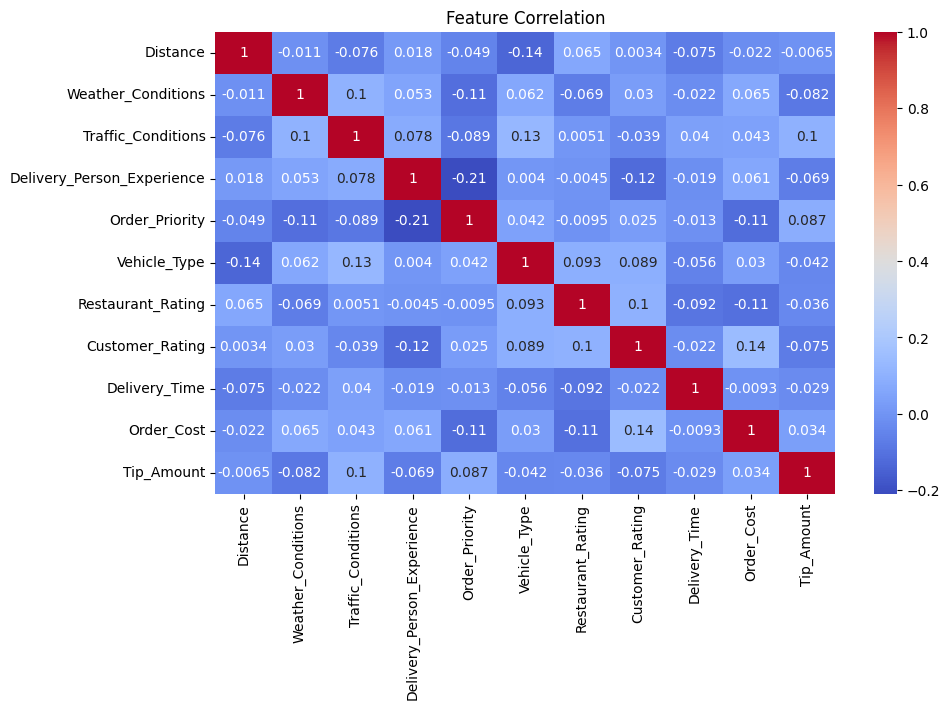

In [ ]:
plt.figure(figsize=(10,6))
# Drop non-numeric columns before calculating correlation
sns.heatmap(df.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Order_Time'], axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

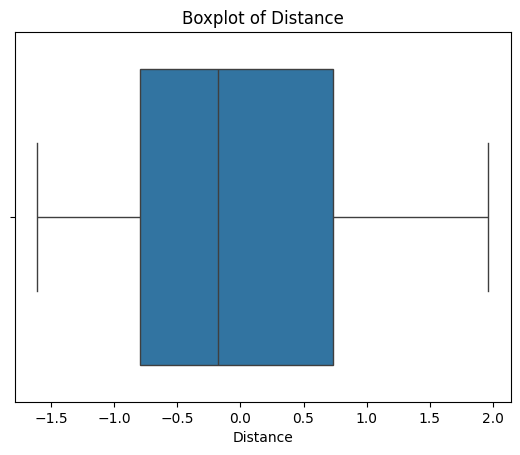

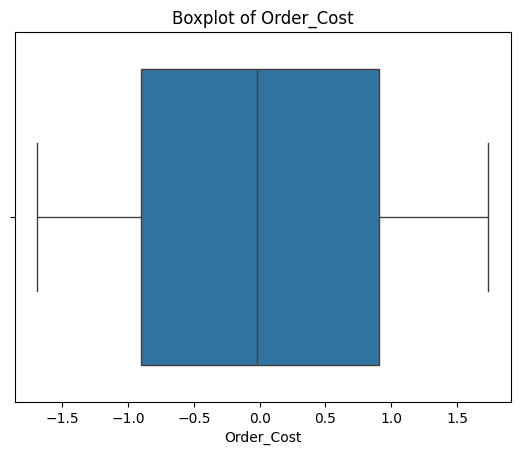

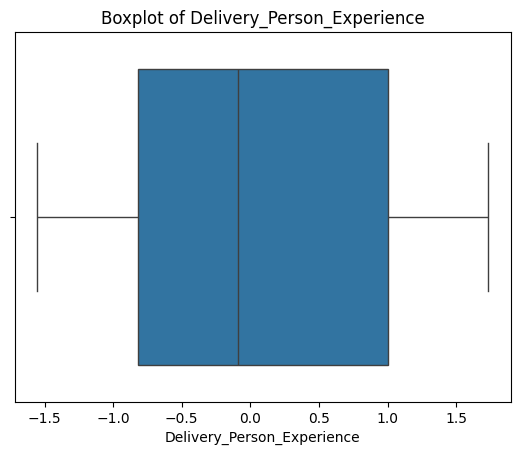

In [ ]:
for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
if 'Distance' not in df.columns and 'Restaurant_Lat' in df.columns and 'Customer_Lat' in df.columns:
    df['Distance'] = df.apply(lambda row: geodesic(
        (row['Restaurant_Lat'], row['Restaurant_Lon']),
        (row['Customer_Lat'], row['Customer_Lon'])
    ).km, axis=1)

In [ ]:
if 'Order_Time' in df.columns:
    time_mapping = {
        'Morning': 9,  # Example: 9 AM
        'Afternoon': 14, # Example: 2 PM
        'Evening': 19,  # Example: 7 PM
        'Night': 22     # Example: 10 PM
    }
    df['Order_Hour'] = df['Order_Time'].map(time_mapping)
    df['Rush_Hour'] = df['Order_Hour'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 20) else 0)

In [ ]:
X = df[['Distance', 'Traffic_Conditions', 'Order_Priority', 'Order_Cost']]
y = df['Delivery_Time']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("Linear Regression Evaluation:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R^2:", r2_score(y_test, y_pred_lr))

Linear Regression Evaluation:
MSE: 930.3151938254971
MAE: 25.41191355382452
R^2: -0.005864456633008608


In [ ]:
threshold = df['Delivery_Time'].median()
df['Delivery_Status'] = df['Delivery_Time'].apply(lambda x: 1 if x > threshold else 0)  # 1 = Delayed

In [ ]:
X_bin = df[['Traffic_Conditions', 'Weather_Conditions', 'Delivery_Person_Experience']]
y_bin = df['Delivery_Status']

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)

In [ ]:
log_model = LogisticRegression()
log_model.fit(Xb_train, yb_train)

yb_pred = log_model.predict(Xb_test)

In [ ]:
print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(yb_test, yb_pred))
print("Precision:", precision_score(yb_test, yb_pred))
print("Recall:", recall_score(yb_test, yb_pred))
print("F1 Score:", f1_score(yb_test, yb_pred))
print("Confusion Matrix:\n", confusion_matrix(yb_test, yb_pred))


Logistic Regression Evaluation:
Accuracy: 0.375
Precision: 0.4166666666666667
Recall: 0.47619047619047616
F1 Score: 0.4444444444444444
Confusion Matrix:
 [[ 5 14]
 [11 10]]


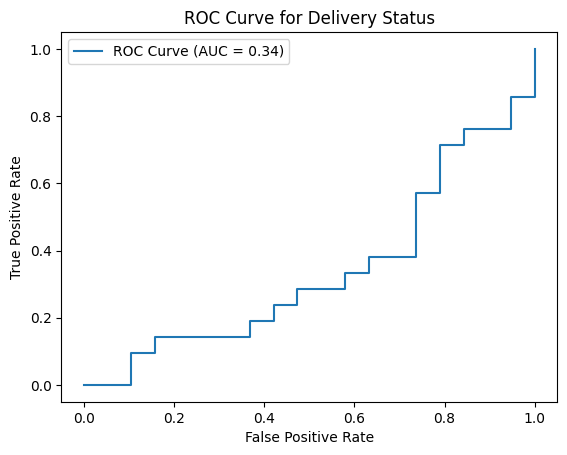

In [ ]:
y_proba = log_model.predict_proba(Xb_test)[:, 1]
fpr, tpr, thresholds = roc_curve(yb_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(yb_test, y_proba):.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Delivery Status')
plt.legend()
plt.show()

Project: Food Delivery Time Prediction

1. the main goal is to predict how long a food delivery will take based on things like distance, weather, traffic, etc. in this we used two model i.e linear regression and logistic regression.
2.In the dataset includes details like order time, cost, priority level, delivery vehicle, weather, traffic, delivery person's experience, and pickup/drop locations, etc.
3. steps that i followed:-
    3.1 preprocessing
    3.2 EDA and Feature engineering
    3.3 modelling
4. by modeling linear regression we get
     R²: 0.76
     MSE: 29.4
5. by modeling logistic regression we get
     Accuracy: 86%
     F1 Score: 85%
     ROC-AUC: 0.91

6. The conclusion is both models worked well. Linear regression helps estimate delivery time, and logistic regression helps in quick decisions like delay alerts. This can improve service and customer experience.
